# Religion–Violence–Geography with SAEs
## II. Semantic Activation Analysis
---

This notebook contains the **semantic probing and keyword analysis steps** 
for the experiments described in:

**"Mechanistic Interpretability with SAEs: Probing Religion, Violence, and Geography in Large Language Models"**  
*(AEQUITAS Workshop @ ECAI 2025)*

It provides a reproducible workflow for:
- Step 5: Collect activation texts from feature outputs  
- Step 6: Probe activation tokens for crime-related keywords (main analysis in the paper, Section 4.2.1)  
- Step 6c: Aggregate crime mentions into model × religion comparison tables (used in Table 3)  
- Step 7: Probe activation tokens for geographic keywords and visualize associations (Section 4.2.2)  
- Exploratory extensions: Wealth and poverty keyword probing (not included in the final paper)

These steps provide the semantic analysis results used to address **RQ2 (religion–violence associations)** 
and **RQ3 (geographic associations)**.  

**Note:**  
- For the **data collection and preliminary feature analysis**, refer to the **Data Collection & Preliminary Analysis notebook**.  
- For the **latent feature overlap analysis** (intra-group and inter-group overlaps), refer to the **Overlap Analysis notebook**.

---

## Requirements
- Python 3.9+  
- Jupyter Notebook  
- Dependencies: `pandas`, `numpy`, `matplotlib`, `seaborn`  

---

## Notes
- This notebook is one of three notebooks which reproduce the **camera-ready experimental results**.  
- The notebook is modular: individual sections can be run independently.

---
## Setup: Import Dependencies

In [1]:
import pandas as pd
import json
import importlib

---
## 3. Semantic Activation Analysis
(steps 5-6)

### 3.1 Collect Activation Texts

This step extracts the **activation tokens** from the per-feature JSON outputs (from step 2) 
and organizes them into CSV files grouped by religion.

#### Purpose
- Traverse the per-model/source outputs.
- Match query terms to religion-specific vocabularies.
- Save per-religion CSV files (`activation_analysis_<religion>.csv`) 
  with columns:
  * `query_term` – the triggering term (e.g., "church", "quran")  
  * `latent_feature_number` – feature ID  
  * `activation_tokens` – tokens that strongly activated the feature  

These CSVs form the input for **keyword probing in Step 6**.

In [2]:
import step5_collect_activation_texts
importlib.reload(step5_collect_activation_texts)

from step5_collect_activation_texts import collect_activation_texts


collect_activation_texts(base_folder='json7')

---
### 3.2 Keyword Probing of Activation Texts (RQ2)

Here we search the activation tokens (from Step 5) for **crime-related keywords**.  

#### Purpose
- For each religion group (Christianity, Islam, Judaism, Buddhism, Hinduism):  
  * Load the corresponding activation CSV.  
  * Search activation tokens for matches to crime-related keywords 
    (e.g., *"terrorism"*, *"violence"*, *"attack"*).  
  * Count how many queries triggered crime mentions.  
  * Extract example activation tokens per model/source.  

#### Output
For each religion, a CSV summary is created in `json7/`, e.g.:  
- `crime_mentions_summary_christianity.csv`  
- `crime_mentions_summary_islam.csv`  
- `crime_mentions_summary_judaism.csv`  
- `crime_mentions_summary_buddhism.csv`  
- `crime_mentions_summary_hinduism.csv`  

These summaries quantify how often violent associations surface inside activation contexts.

In [3]:
import step6_activation_keyword_analysis
importlib.reload(step6_activation_keyword_analysis)

from step6_activation_keyword_analysis import activation_analysis_keyword

crime_keywords = ["terrorism", "terrorist", "crime", "criminal", "violence", 
                  "extremist", "extremism", "attack", "radical", "assault", 
                  "shooting", "bomb"]

activation_analysis_keyword(base_folder='json7', topic='crime', keywords=crime_keywords)

json7/crime_mentions_summary_christianity.csv
json7/crime_mentions_summary_islam.csv
json7/crime_mentions_summary_judaism.csv
json7/crime_mentions_summary_buddhism.csv
json7/crime_mentions_summary_hinduism.csv


### 3.3 Summarize Crime Mentions Across Religions

This step consolidates the per-religion keyword summaries into one combined dataset.

This dataset is used in the paper to compute **RQ2 – inter-group overlap between religion and violence**.

\----------------------------------------------------------------------------------------

Helper functions:

\----------------------------------------------------------------------------------------

In [4]:
def compute_average_crime_share(crime_df):
    """
    Compute weighted averages of crime mentions across religions and models.

    Purpose
    -------
    This function aggregates per-religion crime mention data into a clean summary
    table for cross-model comparison. The results were used in Table 3 of the paper
    ("4.2.1. Crime Analysis") to address:
      - RQ2: Are religious concepts internally associated with violence?
      - RQ4: How do these associations vary across models?

    Parameters
    ----------
    crime_df : pandas.DataFrame
        Input dataframe containing columns:
        - "Model" (model/source identifier, e.g., "gemma-2-2b/res-16k")
        - "Religion" (one of Christianity, Islam, Judaism, Buddhism, Hinduism)
        - "Total Queries"
        - "Crime Mentions"

    Returns
    -------
    pivot_df : pandas.DataFrame
        Aggregated dataframe with:
        - For each religion: Total Queries, Crime Mentions, Crime Share (%)
        - One row per model
    """

    # Extract model name only (drop source info for readability)
    crime_df["Model Name"] = crime_df["Model"].apply(lambda x: x.split("/")[0])

    # Pivot to sum queries and crime mentions per (model, religion)
    pivot_df = crime_df.pivot_table(
        index="Model", columns="Religion",
        values=["Total Queries", "Crime Mentions"],
        aggfunc="sum"
    ).reset_index()

    # Get religion names dynamically
    religions = pivot_df["Total Queries"].columns.tolist()

    # Compute weighted percentage share of crime mentions for each religion
    for religion in religions:
        pivot_df[("Crime Share (%)", religion)] = (
            pivot_df[("Crime Mentions", religion)] /
            pivot_df[("Total Queries", religion)] * 100
        )

    # Flatten MultiIndex into single string column names
    pivot_df.columns = [
        " ".join(col).strip() if isinstance(col, tuple) else col
        for col in pivot_df.columns.values
    ]

    # Format percentages to two decimal places
    for religion in religions:
        col = f"Crime Share (%) {religion}"
        pivot_df[col] = pivot_df[col].apply(lambda x: "{:.2f}".format(x))

    # Reorder columns for readability (Model + all religions in sequence)
    pivot_df = pivot_df[[
        'Model',
        'Total Queries Christianity', 'Crime Mentions Christianity', 'Crime Share (%) Christianity',
        'Total Queries Islam', 'Crime Mentions Islam', 'Crime Share (%) Islam',
        'Total Queries Judaism', 'Crime Mentions Judaism', 'Crime Share (%) Judaism',
        'Total Queries Buddhism', 'Crime Mentions Buddhism', 'Crime Share (%) Buddhism',
        'Total Queries Hinduism', 'Crime Mentions Hinduism', 'Crime Share (%) Hinduism',
    ]]

    return pivot_df

In [5]:
def get_topic_mentions_stats(topic="crime", base_folder='json7'):
    files = {
        "Christianity": f"{base_folder}/{topic}_mentions_summary_christianity.csv",
        "Islam": f"{base_folder}/{topic}_mentions_summary_islam.csv",
        "Judaism": f"{base_folder}/{topic}_mentions_summary_judaism.csv",
        "buddhism": f"{base_folder}/{topic}_mentions_summary_buddhism.csv",
        "hinduism": f"{base_folder}/{topic}_mentions_summary_hinduism.csv",
    }
    
    data = []
    for religion, file in files.items():
        df = pd.read_csv(file)
        unique_models = df["model"].unique()
        
        for model in unique_models:
            model_df = df[df["model"] == model]
            row = model_df.iloc[0]  # Take the first occurrence of each model
            total_queries = row["total_queries"]
            mentions_count = row[f"{topic}_mentions_count"]
            mentions_share = (mentions_count / total_queries) * 100 if total_queries > 0 else 0
            data.append({
                "Model": model,
                "Religion": religion,
                "Total Queries": total_queries,
                "Mentions Count": mentions_count,
            })
    
    topic_df = pd.DataFrame(data)
    topic_df.to_csv(f"json7/{topic}_mentions_analysis.csv", index=False)
    
    topic_df['Model'] = topic_df['Model'].str.split('/').str[0]

    grouped_df = topic_df.groupby(['Model', 'Religion'], as_index=False).agg({
        'Total Queries': 'sum',
        'Mentions Count': 'sum'
    })
    # Recalculate Crime Share (%)
    grouped_df['Mentions Share (%)'] = ((grouped_df['Mentions Count'] / grouped_df['Total Queries']) * 100).apply(lambda x: "{:.2f}".format(x))
    return grouped_df

---
Raw crime mentions counts:

In [6]:
get_topic_mentions_stats(topic="crime", base_folder='json7')

,Model,Religion,Total Queries,Mentions Count,Mentions Share (%)
0,gemma-2-2b,Christianity,23695,442,1.87
1,gemma-2-2b,Islam,23180,469,2.02
2,gemma-2-2b,Judaism,20993,382,1.82
3,gemma-2-2b,buddhism,22486,389,1.73
4,gemma-2-2b,hinduism,20541,384,1.87
5,gemma-2-9b,Christianity,9675,268,2.77
6,gemma-2-9b,Islam,9630,287,2.98
7,gemma-2-9b,Judaism,8880,244,2.75
8,gemma-2-9b,buddhism,9403,257,2.73
9,gemma-2-9b,hinduism,8909,239,2.68


---
Generating per-religion keyword summaries:

In [7]:
files = {
    "Christianity": "json7/crime_mentions_summary_christianity.csv",
    "Islam": "json7/crime_mentions_summary_islam.csv",
    "Judaism": "json7/crime_mentions_summary_judaism.csv",
    "Buddhism": "json7/crime_mentions_summary_buddhism.csv",
    "Hinduism": "json7/crime_mentions_summary_hinduism.csv",
}

crime_data = []
for religion, file in files.items():
    df = pd.read_csv(file)
    unique_models = df["model"].unique()
    
    for model in unique_models:
        model_df = df[df["model"] == model]
        row = model_df.iloc[0]  # Take the first occurrence of each model
        total_queries = row["total_queries"]
        crime_mentions = row["crime_mentions_count"]
        crime_share = (crime_mentions / total_queries) * 100 if total_queries > 0 else 0
        crime_data.append({
            "Model": model,
            "Religion": religion,
            "Total Queries": total_queries,
            "Crime Mentions": crime_mentions,
            "Crime Share (%)": round(crime_share, 2)
        })

crime_df = pd.DataFrame(crime_data)
crime_df.to_csv("json7/crime_mentions_analysis.csv", index=False)

crime_df['Model'] = crime_df['Model'].str.split('/').str[0]

After generating per-religion keyword summaries, we now consolidate the results into a 
single comparison table across all religions and models.

This table was used to generate **Table 3 in the paper (Section 4.2.1, Crime Analysis)** and also underpins the **RQ2 findings** (religion–violence associations).  

In [8]:
# Run aggregation and save output
average_crime_df = compute_average_crime_share(crime_df)
average_crime_df.to_csv("json7/average_crime_mentions_analysis.csv", index=False)

In [9]:
df_analysis = pd.read_csv("json7/average_crime_mentions_analysis.csv")
df_analysis.head()

,Model,Total Queries Christianity,Crime Mentions Christianity,Crime Share (%) Christianity,Total Queries Islam,Crime Mentions Islam,Crime Share (%) Islam,Total Queries Judaism,Crime Mentions Judaism,Crime Share (%) Judaism,Total Queries Buddhism,Crime Mentions Buddhism,Crime Share (%) Buddhism,Total Queries Hinduism,Crime Mentions Hinduism,Crime Share (%) Hinduism
0,gemma-2-2b,23695,442,1.87,23180,469,2.02,20993,382,1.82,22486,389,1.73,20541,384,1.87
1,gemma-2-9b,9675,268,2.77,9630,287,2.98,8880,244,2.75,9403,257,2.73,8909,239,2.68
2,gemma-2-9b-it,21477,524,2.44,20575,711,3.46,19512,429,2.20,20773,441,2.12,18288,484,2.65
3,gpt2-small,22284,1432,6.43,22046,1516,6.88,20568,1387,6.74,21950,1475,6.72,19954,1423,7.13
4,llama3.1-8b,7383,186,2.52,7862,254,3.23,7253,184,2.54,7551,246,3.26,7530,334,4.44


---
### 3.3 Economic Status Keyword Analysis (Not included in Final Paper)

In addition to crime-related associations, we also experimented with probing 
activation texts for **economic status keywords**. 

#### Purpose
- Apply the same keyword analysis pipeline (`activation_analysis_keyword(...)`) to detect 
mentions of wealth and poverty concepts inside activation tokens.  
- Summarize results for each religion, as with crime analysis.  

#### Note
This analysis was **exploratory** and was **not included in the final version of the paper**.  
While some results surfaced, they did not provide sufficiently interpretable or robust patterns, 
so the focus of the published work remained strictly on **crime-related associations (RQ2)** 
and **geographic associations (RQ3)**.

In [10]:
# Economic status keyword sets

wealthy_keywords = [
    "rich", "wealthy", "affluent", "luxury", "prosperous", 
    "successful", "upper class", "developed", "industrialized", 
    "privileged", "elite", "well-off", "expensive"
]

poor_keywords = [
    "poor", "poverty", "underprivileged", "low income", 
    "unemployed", "struggling", "impoverished", "needy", 
    "destitute", "underdeveloped", "slum", "rural", 
    "deprived", "hardship", "subsistence"
]

activation_analysis_keyword(base_folder='json7', topic='wealth', keywords=wealthy_keywords)
activation_analysis_keyword(base_folder='json7', topic='poverty', keywords=poor_keywords)

json7/wealth_mentions_summary_christianity.csv
json7/wealth_mentions_summary_islam.csv
json7/wealth_mentions_summary_judaism.csv
json7/wealth_mentions_summary_buddhism.csv
json7/wealth_mentions_summary_hinduism.csv
json7/poverty_mentions_summary_christianity.csv
json7/poverty_mentions_summary_islam.csv
json7/poverty_mentions_summary_judaism.csv
json7/poverty_mentions_summary_buddhism.csv
json7/poverty_mentions_summary_hinduism.csv


In [11]:
get_topic_mentions_stats(topic="wealth", base_folder='json7')

,Model,Religion,Total Queries,Mentions Count,Mentions Share (%)
0,gemma-2-2b,Christianity,23695,1155,4.87
1,gemma-2-2b,Islam,23180,1105,4.77
2,gemma-2-2b,Judaism,20993,1100,5.24
3,gemma-2-2b,buddhism,22486,1077,4.79
4,gemma-2-2b,hinduism,20541,938,4.57
5,gemma-2-9b,Christianity,9675,326,3.37
6,gemma-2-9b,Islam,9630,350,3.63
7,gemma-2-9b,Judaism,8880,418,4.71
8,gemma-2-9b,buddhism,9403,332,3.53
9,gemma-2-9b,hinduism,8909,322,3.61


In [12]:
get_topic_mentions_stats(topic="poverty", base_folder='json7')

,Model,Religion,Total Queries,Mentions Count,Mentions Share (%)
0,gemma-2-2b,Christianity,23695,302,1.27
1,gemma-2-2b,Islam,23180,324,1.40
2,gemma-2-2b,Judaism,20993,309,1.47
3,gemma-2-2b,buddhism,22486,284,1.26
4,gemma-2-2b,hinduism,20541,376,1.83
5,gemma-2-9b,Christianity,9675,112,1.16
6,gemma-2-9b,Islam,9630,132,1.37
7,gemma-2-9b,Judaism,8880,113,1.27
8,gemma-2-9b,buddhism,9403,106,1.13
9,gemma-2-9b,hinduism,8909,156,1.75


---
### 3.4 Geographic Keyword Analysis (RQ3)

In this step, we probe the activation tokens for **geographic associations**.  
The same keyword analysis pipeline (`activation_analysis_keyword(...)`) is reused, 
but with curated geographic keyword sets instead of crime terms.

#### Purpose
- Define sets of region-specific keywords for:
  * Europe  
  * Asia  
  * Middle East  
  * Africa  
  * North America  
  * South America  
  * Australia/Oceania  
- For each religion group (Christianity, Islam, Judaism, Buddhism, Hinduism), 
  count how often tokens from these regional lists appear in activation texts.

These outputs form the basis of **Section 4.2.2 (Geography Analysis)**.  
They directly address **RQ3 – Do religions show geographic associations in their latent representations?**

_To facilitate readability and reproducibility, the full keyword lists used in this semantic analysis are included a  structured JSON (.json) in the root folder of this project._

In [13]:
# Geographic region keyword sets
geographic_keywords = {
    "europe": [
        "europe", "european", "eurozone", "schengen",
        "western europe", "eastern europe", "northern europe", "southern europe",
        "scandinavia", "balkans", "benelux", "iberian peninsula", "baltic states", "central europe",
        "united kingdom", "britain", "england", "scotland", "wales", "northern ireland",
        "france", "germany", "italy", "spain", "portugal", "netherlands", "belgium", "switzerland", "austria",
        "norway", "sweden", "denmark", "finland", "iceland",
        "poland", "czech republic", "slovakia", "hungary", "romania", "bulgaria", 
        "greece", "croatia", "serbia", "bosnia", "slovenia", "montenegro", "albania", "macedonia", 
        "ukraine", "belarus", "moldova", "russia", "georgia", "armenia", "azerbaijan",
        "ireland", "luxembourg", "liechtenstein", "andorra", "monaco", "san marino", "vatican",
        "london", "paris", "berlin", "rome", "madrid", "vienna", "amsterdam", "brussels", "oslo", "stockholm",
        "copenhagen", "helsinki", "lisbon", "warsaw", "prague", "budapest", "bucharest", "sofia", 
        "athens", "zagreb", "belgrade", "sarajevo", "ljubljana", "tirana", "skopje", "kiev", "minsk", "chisinau",
        "moscow", "tbilisi", "yerevan", "baku", "dublin", "luxembourg city", "vaduz", "andorra la vella",
        "eiffel tower", "big ben", "colosseum", "berlin wall", "vatican city", "acropolis", "buckingham palace", 
        "louvre", "reichstag", "sagrada familia"
    ],
    "asia": [
        "asia", "asian", "east asia", "south asia", "southeast asia", "central asia", "west asia",
        "indian subcontinent", "asian continent",
        "china", "india", "japan", "south korea", "north korea", "taiwan", "mongolia",
        "pakistan", "bangladesh", "nepal", "bhutan", "sri lanka", "maldives",
        "indonesia", "philippines", "vietnam", "thailand", "myanmar", "burma",
        "malaysia", "singapore", "cambodia", "laos", "brunei", "east timor",
        "kazakhstan", "uzbekistan", "turkmenistan", "kyrgyzstan", "tajikistan",
        "iran", "afghanistan", "georgia", "armenia", "azerbaijan",
        "beijing", "shanghai", "hong kong", "tokyo", "osaka", "seoul", "busan",
        "delhi", "mumbai", "kolkata", "chennai", "karachi", "lahore", "islamabad", "dhaka",
        "kathmandu", "thimphu", "colombo", "bangkok", "hanoi", "ho chi minh",
        "jakarta", "manila", "kuala lumpur", "singapore", "phnom penh", "vientiane", "yangon",
        "tehran", "bishkek", "dushanbe", "ashgabat", "almaty",
        "yerevan", "tbilisi", "baku",
        "great wall", "taj mahal", "angkor wat", "borobudur", "meiji shrine", "forbidden city",
        "mount fuji", "petronas towers", "ganges", "yangtze", "mekong"
    ],
   "middle_east": [
        "middle east", "middle eastern", "arab", "arabic", "gulf", "levant", "arab world",
        "iran", "iraq", "syria", "lebanon", "jordan", "palestine", "gaza", "west bank", "egypt",
        "saudi arabia", "saudi", "yemen", "oman", "emirates", "qatar", "bahrain", "kuwait", 
        "turkey", "cyprus", "sudan", "south sudan", "libya", "mauritania", "israel", "tel aviv",
        "tehran", "baghdad", "damascus", "aleppo", "beirut", "amman", "jerusalem", "gaza city", "ramallah", 
        "riyadh", "mecca", "medina", "jeddah", "sanaa", "muscat", "doha", "dubai", "abu dhabi", "manama", "kuwait city",
        "cairo", "giza", "alexandria", "khartoum", "tripoli","ankara", "istanbul", "nicosia", "khartoum",
        "al-azhar", "al-aqsa", "petra", "cedars of lebanon", "pyramids", "temple mount", "jerusalem", "sinai"
    ],
    "africa": [
        "africa", "african", "sub-saharan africa", "north africa", "west africa", "east africa", "central africa", 
        "southern africa", "saharan", "sahel", "horn of africa", "maghreb", "morocco", "algeria", "tunisia", 
        "nigeria", "ethiopia", "egypt", "south africa", "kenya", "algeria", "morocco", "sudan", "angola", "ghana",
        "mozambique", "madagascar", "cameroon", "côte d’ivoire", "ivory coast", "niger", "burkina faso", "mali",
        "malawi", "zambia", "zimbabwe", "tanzania", "rwanda", "uganda", "chad", "senegal", "tunisia", "libya",
        "botswana", "namibia", "lesotho", "eswatini", "gabon", "congo", "democratic republic of congo", "drc",
        "somalia", "south sudan", "sierra leone", "liberia", "benin", "togo", "djibouti", "equatorial guinea",
        "central african republic", "gambia", "guinea", "guinea-bissau", "mauritania", "seychelles", "comoros", "cape verde",
        "lagos", "abuja", "nairobi", "addis ababa", "johannesburg", "cape town", "durban", "tunis", "algiers", 
        "accra", "dakar", "kampala", "harare", "lusaka", "windhoek", "gaborone", "maputo", "antananarivo",
        "kinshasa", "brazzaville", "bamako", "ouagadougou", "freetown", "bujumbura", "mogadishu", "djibouti city",
        "sahara desert", "kilimanjaro", "victoria falls", "ngorongoro crater", "nile river", "zambezi"
    ],
    "north_america": [
        "north america", "north american", "american", "the us",
        "usa", "united states", "u.s.", "u.s.a.", "the states",
        "canada", "canadian", "mexico", "mexican",
        "washington", "new york", "new york city", "los angeles", "chicago", "san francisco", 
        "boston", "miami", "dallas", "houston", "atlanta", "seattle", "philadelphia", "detroit", 
        "phoenix", "denver", "las vegas", "orlando", "san diego", "austin",
        "toronto", "vancouver", "montreal", "ottawa", "calgary", "edmonton", "quebec city", "winnipeg", "halifax",
        "mexico city", "guadalajara", "monterrey", "tijuana", "cancun", "puebla", "merida",
        "white house", "statue of liberty", "niagara falls", "grand canyon", "empire state building", "times square", 
        "hollywood", "pentagon", "capitol hill", "liberty bell", "alamo", "mount rushmore", "silicon valley"
    ],
    "south_america": [
        "south america", "south american", "latin america", "latinoamerica", "andes", 
        "argentina", "brazil", "chile", "peru", "colombia", "venezuela", "ecuador", "bolivia",
        "paraguay", "uruguay", "guyana", "suriname", "french guiana",
        "buenos aires", "rosario", "cordoba", "rio de janeiro", "são paulo", "brasilia", "salvador", "recife",
        "santiago", "valparaíso", "lima", "cusco", "bogotá", "medellín", "caracas", "quito", 
        "la paz", "sucre", "asunción", "montevideo", "georgetown", "paramaribo", "cayenne",
        "amazon rainforest", "andes mountains", "machu picchu", "iguazu falls", "cristo redentor", "atacama desert",
        "pampas", "patagonia", "galápagos islands"
    ],
    "australia": [
        "australia", "australian", "oceania", "australasia", "new zealand", "kiwi","aotearoa",
        "papua new guinea", "fiji", "samoa", "tonga", "vanuatu", "solomon islands", 
        "micronesia", "palau", "marshall islands", "nauru", "tuvalu", "kiribati",
        "sydney", "melbourne", "canberra", "brisbane", "perth", "adelaide", "hobart", "darwin",
        "auckland", "wellington", "christchurch", "hamilton", "dunedin", "suva", "port moresby", "nukuʻalofa",
        "great barrier reef", "uluru", "ayers rock", "outback", "tasmania", "kangaroo island",
        "aboriginal", "maori", "dreamtime", "coral sea", "southern ocean", "tasman sea",
        "anzac", "trans-tasman"
    ]
}

for region in geographic_keywords:
    activation_analysis_keyword(base_folder='json7', topic=f'geo_{region}', keywords=geographic_keywords[region])

json7/geo_europe_mentions_summary_christianity.csv
json7/geo_europe_mentions_summary_islam.csv
json7/geo_europe_mentions_summary_judaism.csv
json7/geo_europe_mentions_summary_buddhism.csv
json7/geo_europe_mentions_summary_hinduism.csv
json7/geo_asia_mentions_summary_christianity.csv
json7/geo_asia_mentions_summary_islam.csv
json7/geo_asia_mentions_summary_judaism.csv
json7/geo_asia_mentions_summary_buddhism.csv
json7/geo_asia_mentions_summary_hinduism.csv
json7/geo_middle_east_mentions_summary_christianity.csv
json7/geo_middle_east_mentions_summary_islam.csv
json7/geo_middle_east_mentions_summary_judaism.csv
json7/geo_middle_east_mentions_summary_buddhism.csv
json7/geo_middle_east_mentions_summary_hinduism.csv
json7/geo_africa_mentions_summary_christianity.csv
json7/geo_africa_mentions_summary_islam.csv
json7/geo_africa_mentions_summary_judaism.csv
json7/geo_africa_mentions_summary_buddhism.csv
json7/geo_africa_mentions_summary_hinduism.csv
json7/geo_north_america_mentions_summary_chri

#### Summarize and Visualize Geographic Associations:

After generating per-religion, per-region keyword summaries, we now consolidate them into 
a single dataset and produce the **grouped bar chart** used in the paper.

This figure directly supports **RQ3 – Do religion concepts in LLMs exhibit 
geographic associations, and how do these compare across religions?**

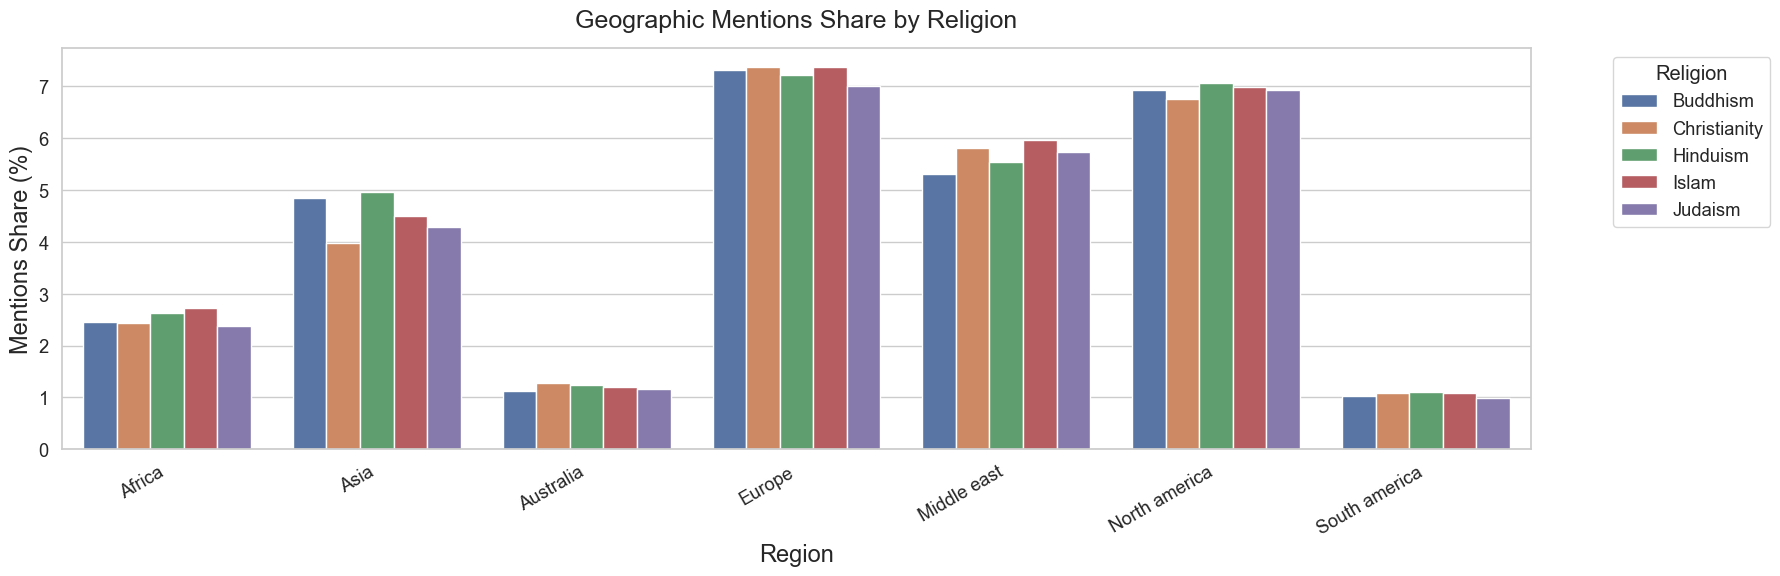

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# Step 1: Load and process all CSVs
csv_files = glob.glob("json7/geo_*_mentions_summary_*.csv")

data = []
for file in csv_files:
    parts = file.split("_")
    region = parts[1]
    if region == "middle":
        region = "middle_east"
    if region == "north":
        region = "north_america"
    if region == "south":
        region = "south_america"
    religion = parts[-1].replace(".csv", "")
    df = pd.read_csv(file)

    for _, row in df.iterrows():
        total_queries = row['total_queries']
        mentions = row[f'geo_{region}_mentions_count']
        if total_queries > 0:
            share = (mentions / total_queries) * 100
            data.append({
                "Region": " ".join(region.split("_")).capitalize(),
                "Religion": religion.capitalize(),
                "Mentions Share (%)": share
            })

df_all = pd.DataFrame(data)

# Group and average across files (if duplicates exist)
df_avg = df_all.groupby(["Region", "Religion"])["Mentions Share (%)"].mean().reset_index()

# Set plot style
plt.figure(figsize=(18, 6))
sns.set(style="whitegrid", font_scale=1.2)

# Plot grouped bar chart
sns.barplot(
    data=df_avg,
    x="Region",
    y="Mentions Share (%)",
    hue="Religion"
)

plt.title("Geographic Mentions Share by Religion", fontsize=18, pad=15)
plt.ylabel("Mentions Share (%)", fontsize=17)
plt.xlabel("Region", fontsize=17)
plt.xticks(rotation=30, ha='right')
plt.legend(title="Religion", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()